In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import cv2
from ImageData import ImageDataset
from pca import PCA
from alignement import process_single_image

### Load ImageData object from binary with pickle

In [2]:
with open("../../data/image_matrix.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

<class 'ImageData.ImageDataset'>


### Initialize a PCA object
**Looong runtime**<br>
Save to binary with pickle after running once to avoid re-running.

In [3]:
load = False
if load:
    print("loading PCA model from file...")
    with open("../../data/pca_model.pkl", "rb") as f:
        pca = pickle.load(f)
else:
    pca = PCA(n_components=1000)
    pca.fit(data)

Using dual PCA approach.
Computing smaller covariance matrix...
Computing eigenvalues and eigenvectors of the smaller covariance matrix...
Computing eigenvalues and eigenvectors of the smaller covariance matrix...
Computed 1702 principal components from 1791 samples.
Computed 1702 principal components from 1791 samples.


In [4]:
with open("../../data/pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

### Testing different reconstruction component counts
Try different n_components values to see how it affects reconstruction quality.

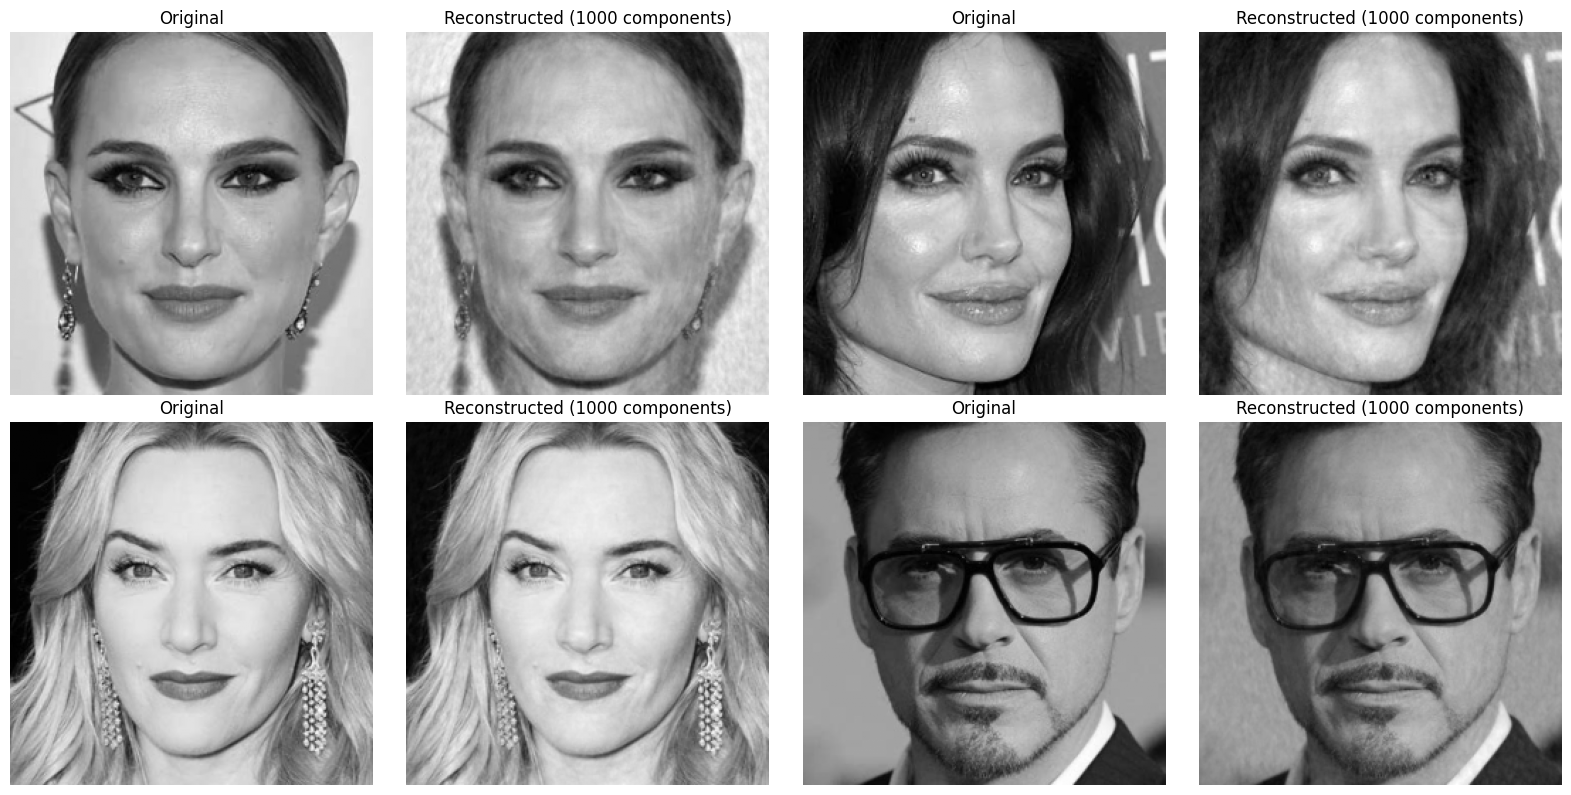

In [5]:
# Select 4 random indices
random_indices = np.random.choice(len(data.data), 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, idx in enumerate(random_indices):
    row = i // 2
    col = (i % 2) * 2
    
    # Get original image
    original_img = data[idx]
    
    # Transform and reconstruct
    X_transformed, X_reconstructed = pca.transform_and_reconstruct(original_img)
    
    # Plot original
    axes[row, col].imshow(original_img.reshape(data.image_height, data.image_width), cmap='gray')
    axes[row, col].set_title(f'Original')
    axes[row, col].axis('off')
    
    # Plot reconstructed
    axes[row, col+1].imshow(X_reconstructed.reshape(data.image_height, data.image_width), cmap='gray')
    axes[row, col+1].set_title(f'Reconstructed ({pca.n_components} components)')
    axes[row, col+1].axis('off')

plt.tight_layout()
plt.show()

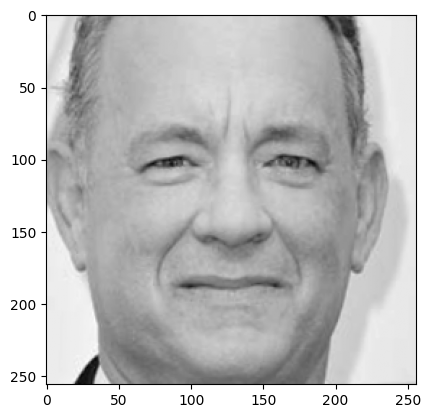

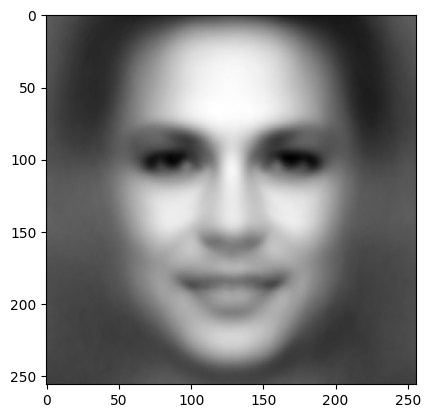

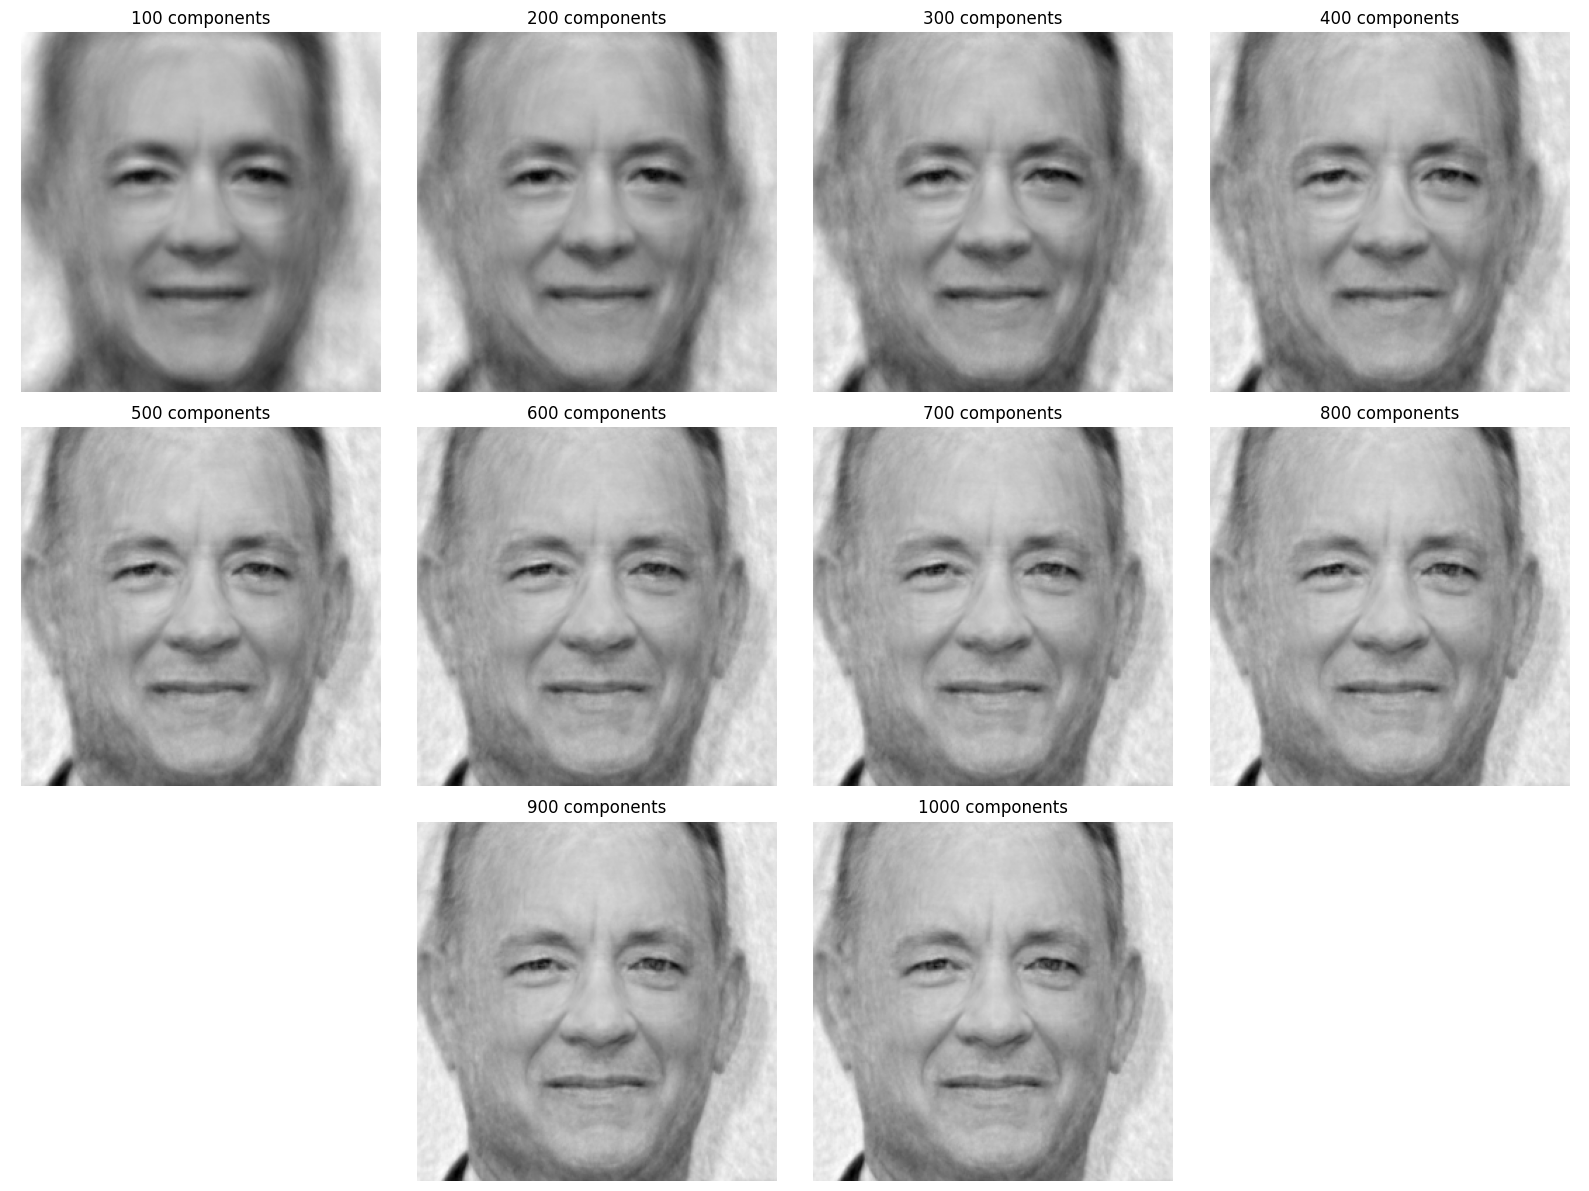

In [6]:
test_img = data[1610]
plt.imshow(test_img.reshape(data.image_height, data.image_width), cmap='gray')
plt.show()

plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')
plt.show()


test_img_reconstructed = []
for n in range(100, 1100, 100):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(test_img, n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(3, 4, figsize=(16, 12))  # 3 rows, 4 columns

# First row - 4 images
for i in range(4):
    axes[0, i].imshow(test_img_reconstructed[i].reshape(data.image_height, data.image_width), cmap='gray')
    axes[0, i].set_title(f'{(i + 1)*100} components')
    axes[0, i].axis('off')

# Second row - 4 images
for i in range(4):
    axes[1, i].imshow(test_img_reconstructed[i+4].reshape(data.image_height, data.image_width), cmap='gray')
    axes[1, i].set_title(f'{(i + 5)*100} components')
    axes[1, i].axis('off')

# Third row - 2 centered images (use columns 1 and 2)
axes[2, 0].axis('off')  # Hide first column
axes[2, 1].imshow(test_img_reconstructed[8].reshape(data.image_height, data.image_width), cmap='gray')
axes[2, 1].set_title(f'900 components')
axes[2, 1].axis('off')
axes[2, 2].imshow(test_img_reconstructed[9].reshape(data.image_height, data.image_width), cmap='gray')
axes[2, 2].set_title(f'1000 components')
axes[2, 2].axis('off')
axes[2, 3].axis('off')  # Hide last column

plt.tight_layout()
plt.savefig('visuals/different_num_of_components.png', dpi=300)
plt.show()

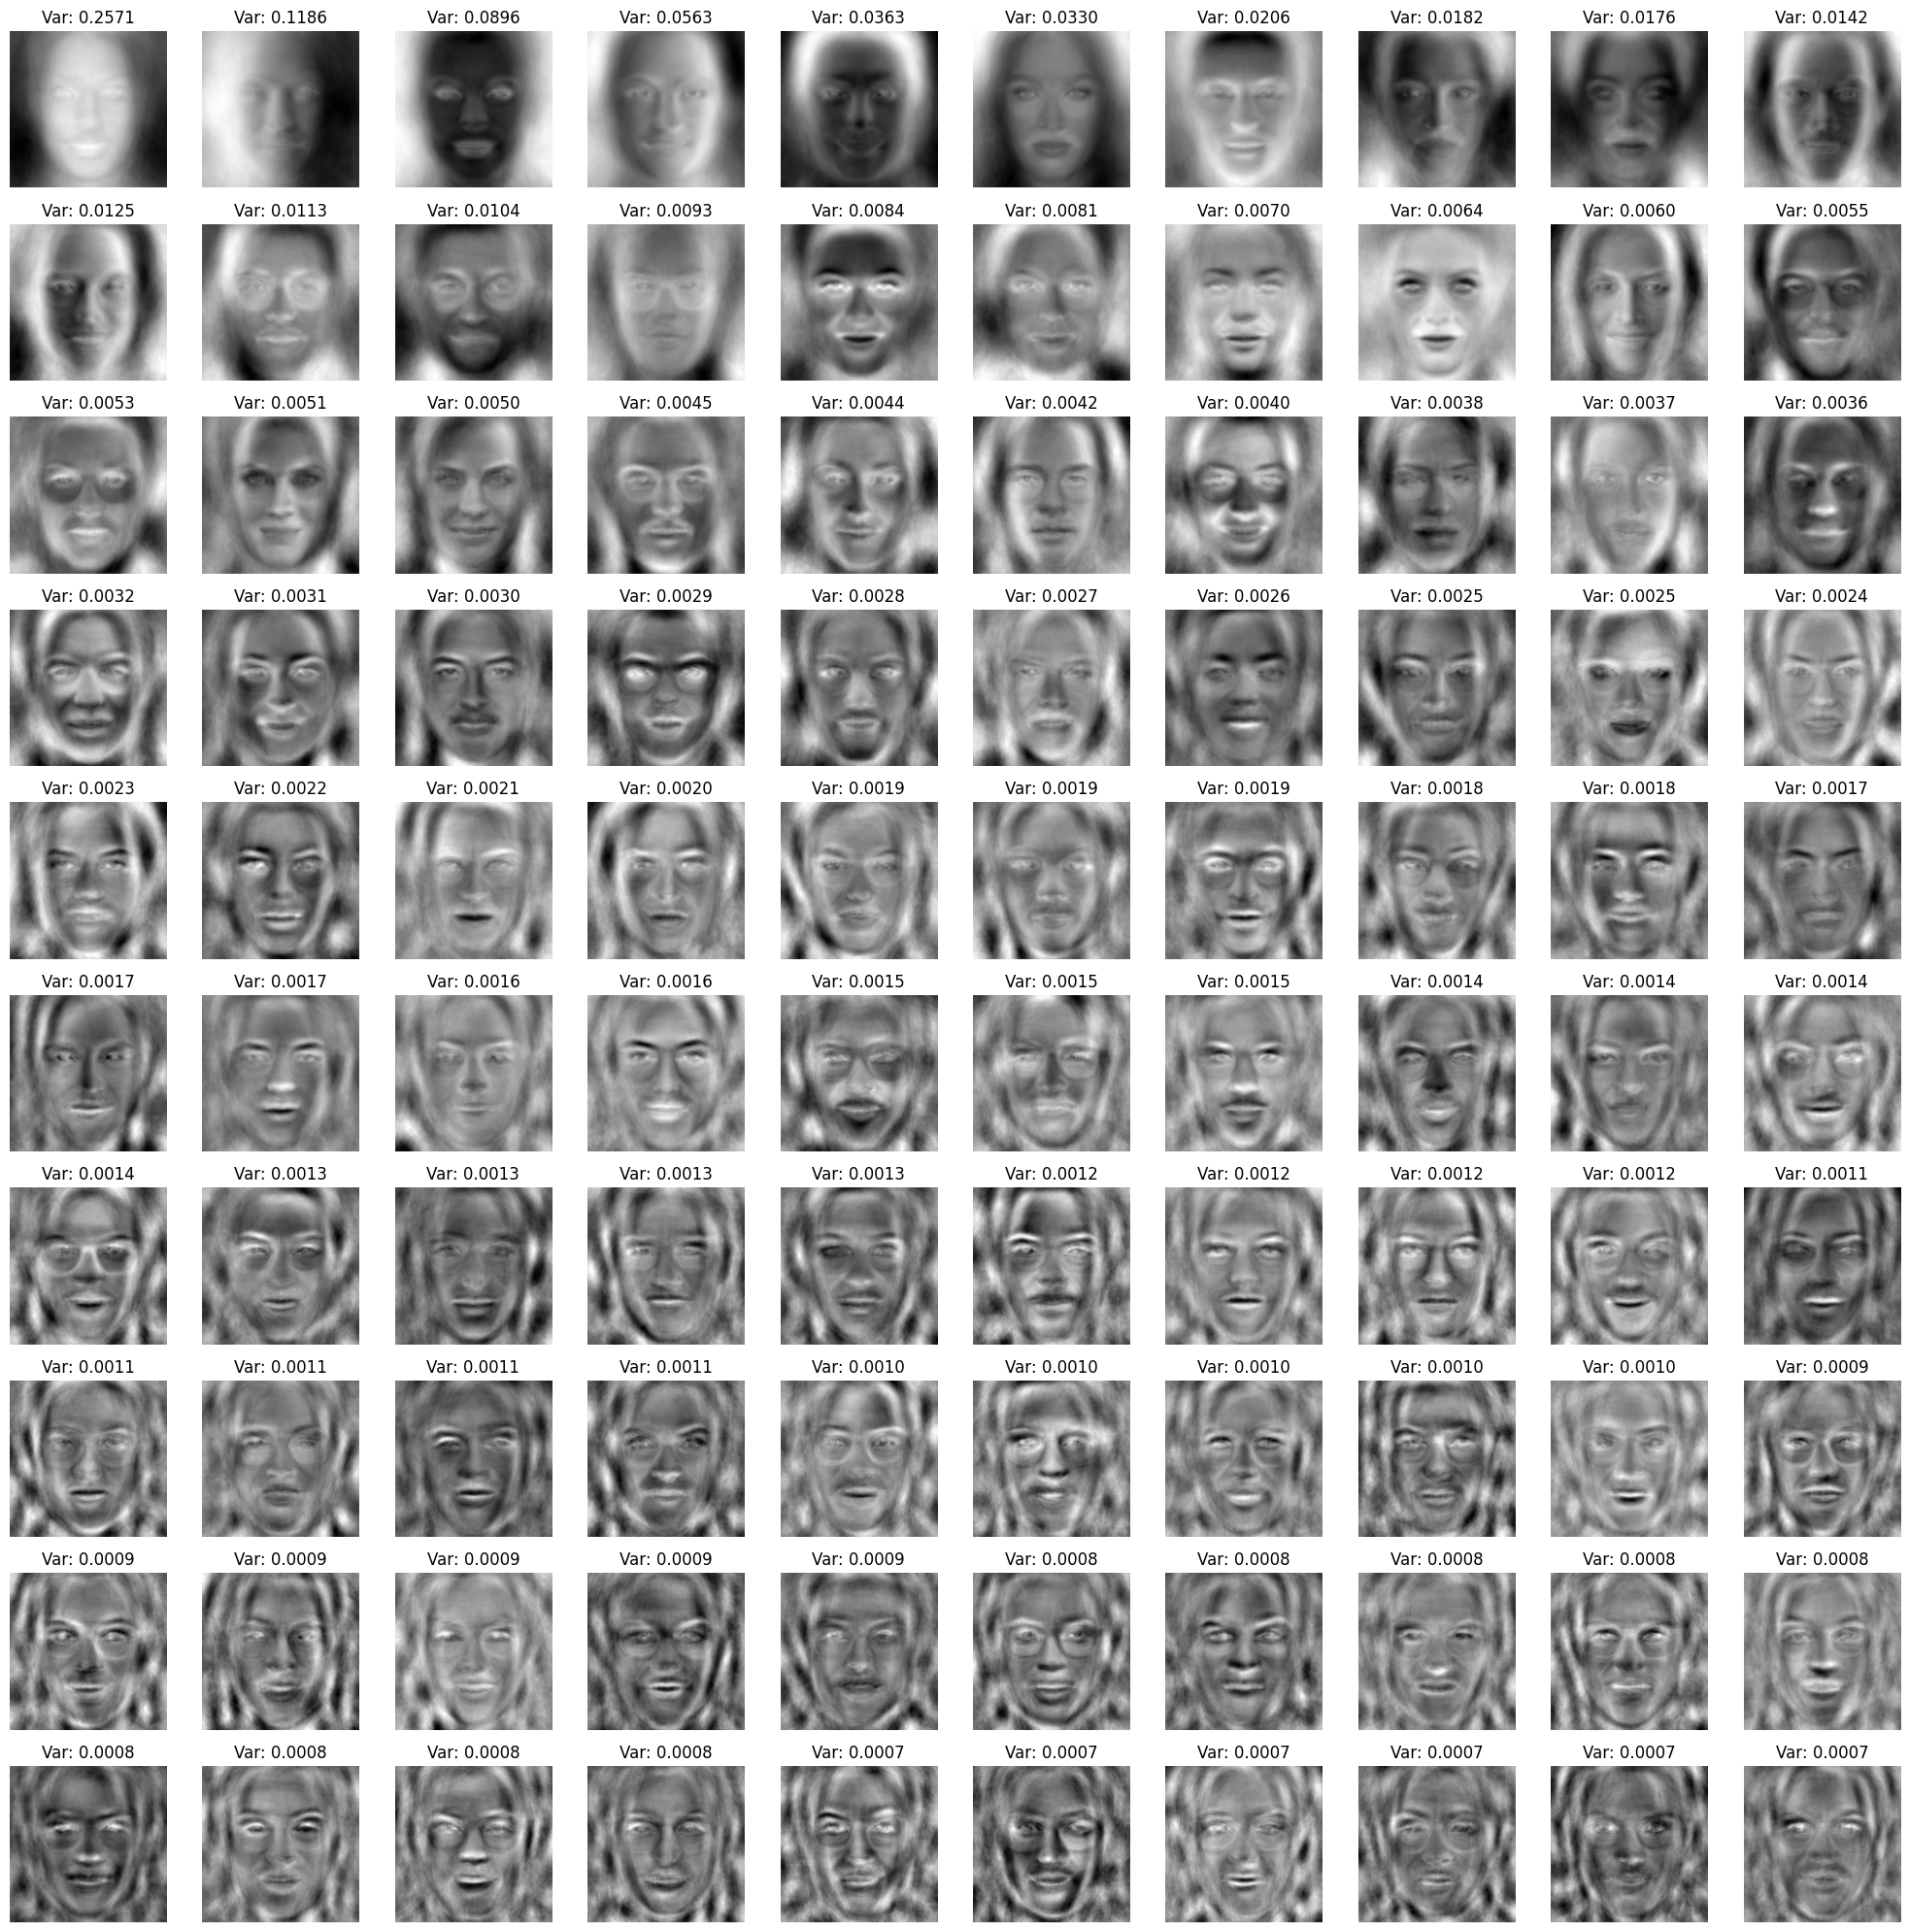

In [7]:
components = pca.components
eigenvals, explained_variance = pca.explained_variance()

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()

for i in range(100):
    ax = axes[i]
    ax.imshow(components[:,i].reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'Var: {explained_variance[i]:.4f}')
    ax.axis('off')
plt.tight_layout()
plt.show()


**As the principal components have been computed on a set of images of only 18 different celbrities, I am expecting it to be sort of "overfitted" to this specific dataset. This means that while the PCA model may perform well on these images, it might not generalize effectively to new, unseen images of different people. I try to project and reconstruct an image of me!**


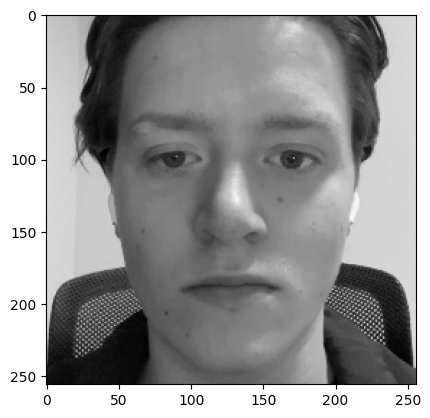

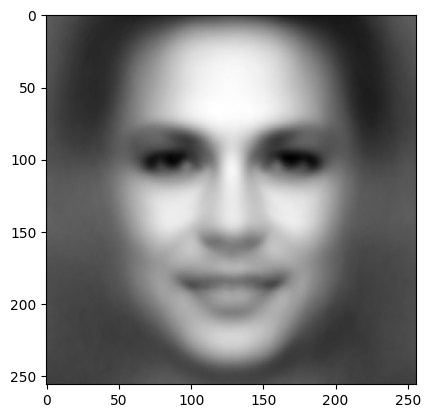

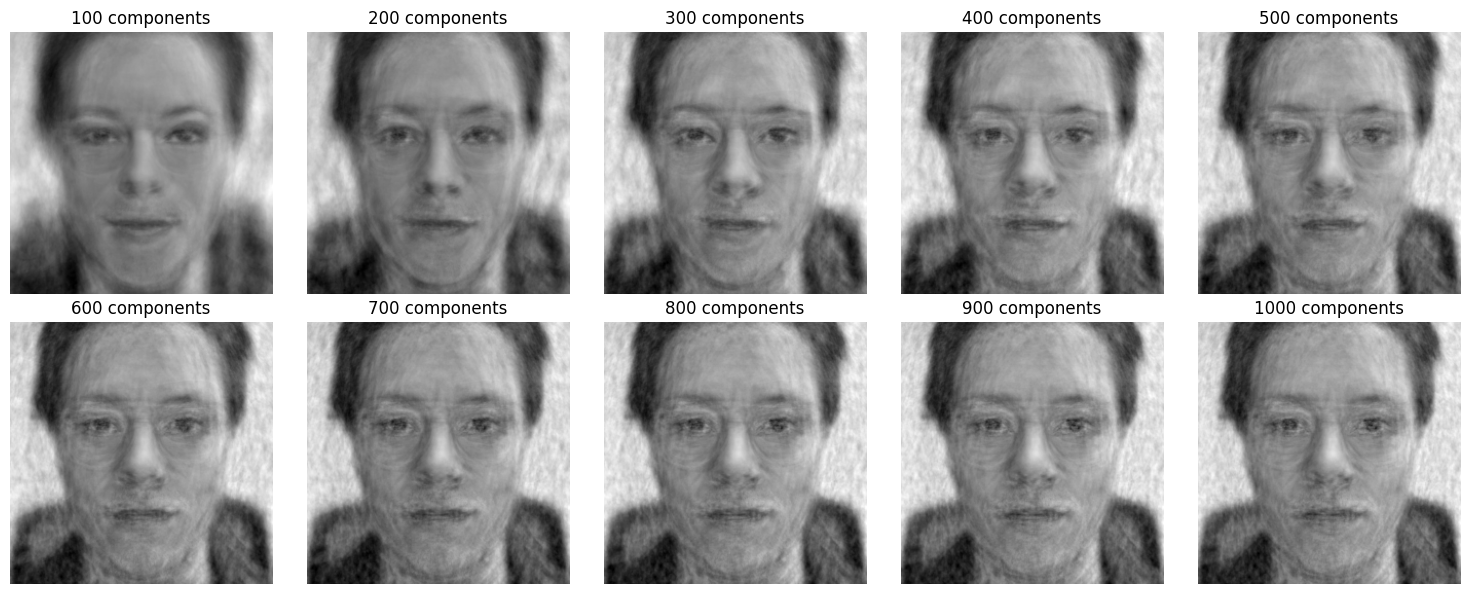

In [8]:
selfie_path = "../../data/nico_selfie.jpg"
aligned_success, info = process_single_image(
    selfie_path,
    out_path="../../data/nico_selfie_aligned.jpg",
    grayscale_after=True,
    normalize_0_1=True,
    min_conf=0.9
)

selfie = cv2.imread("../../data/nico_selfie_aligned.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(selfie, cmap='gray')
plt.show()
plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')

selfie_transformed = pca.transform(selfie.flatten())


test_img_reconstructed = []
for n in range(100, 1100, 100):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(selfie.flatten(), n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 1)*100} components')
    ax.axis('off')

plt.tight_layout()
plt.show()



### Another one

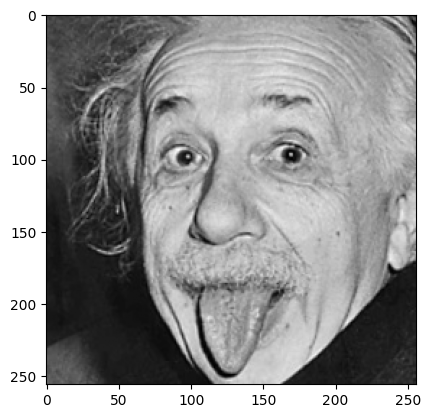

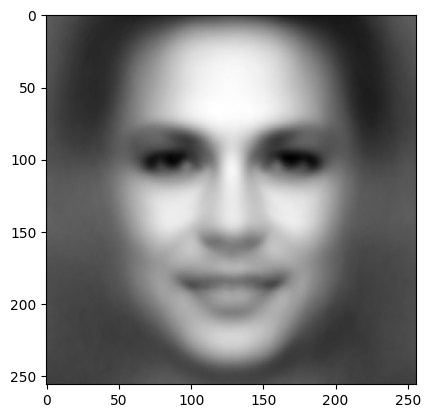

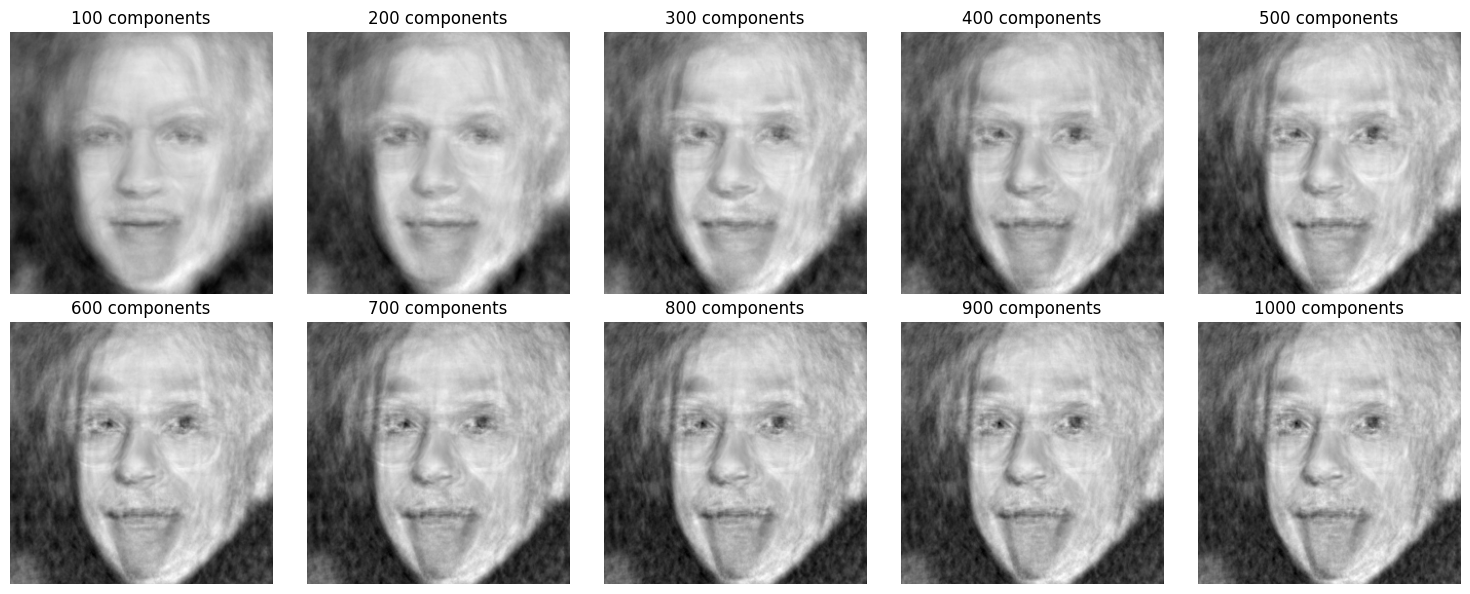

In [9]:
selfie_path = "../../data/einstein.jpg"
aligned_success, info = process_single_image(
    selfie_path,
    out_path="../../data/einstein_aligned.jpg",
    grayscale_after=True,
    normalize_0_1=True,
    min_conf=0.9
)

selfie = cv2.imread("../../data/einstein_aligned.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(selfie, cmap='gray')
plt.show()
plt.imshow(data.mean.reshape(data.image_height, data.image_width), cmap='gray')

selfie_transformed = pca.transform(selfie.flatten())


test_img_reconstructed = []
for n in range(100, 1100, 100):
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(selfie.flatten(), n)
    test_img_reconstructed.append(reconstructed)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, test_img_reconstructed)):
    ax.imshow(img.reshape(data.image_height, data.image_width), cmap='gray')
    ax.set_title(f'{(i + 1)*100} components')
    ax.axis('off')

plt.tight_layout()
plt.show()



### visualize variance explained by components + Cumulative variance plot

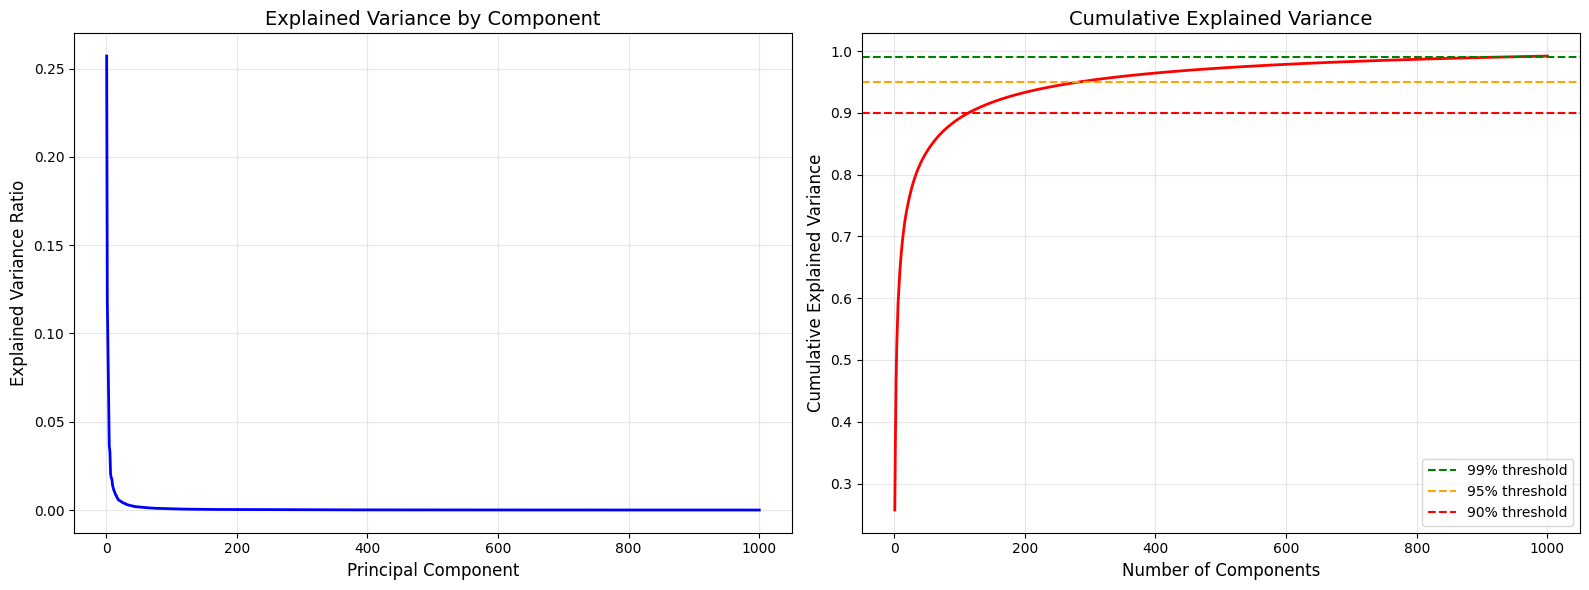

Components needed for 90% variance: 114
Components needed for 95% variance: 284
Components needed for 99% variance: 916
Total variance explained by 1000 components: 0.9920


In [10]:
eigenvalues, var_explained = pca.explained_variance()

cumulative_variance = np.cumsum(var_explained)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Explained Variance
ax1.plot(range(1, len(var_explained) + 1), var_explained, 'b-', linewidth=2)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
ax1.set_title('Explained Variance by Component', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative Explained Variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'r-', linewidth=2)
ax2.axhline(y=0.99, color='g', linestyle='--', label='99% threshold')
ax2.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax2.set_title('Cumulative Explained Variance', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visuals/explained_variance.png', dpi=300)
plt.show()

# Find how many components needed for 90% and 95% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {n_components_99}")
print(f"Total variance explained by {pca.n_components} components: {cumulative_variance[-1]:.4f}")

### Visualize original images with the amount of components needed for 90-95% variance preservation

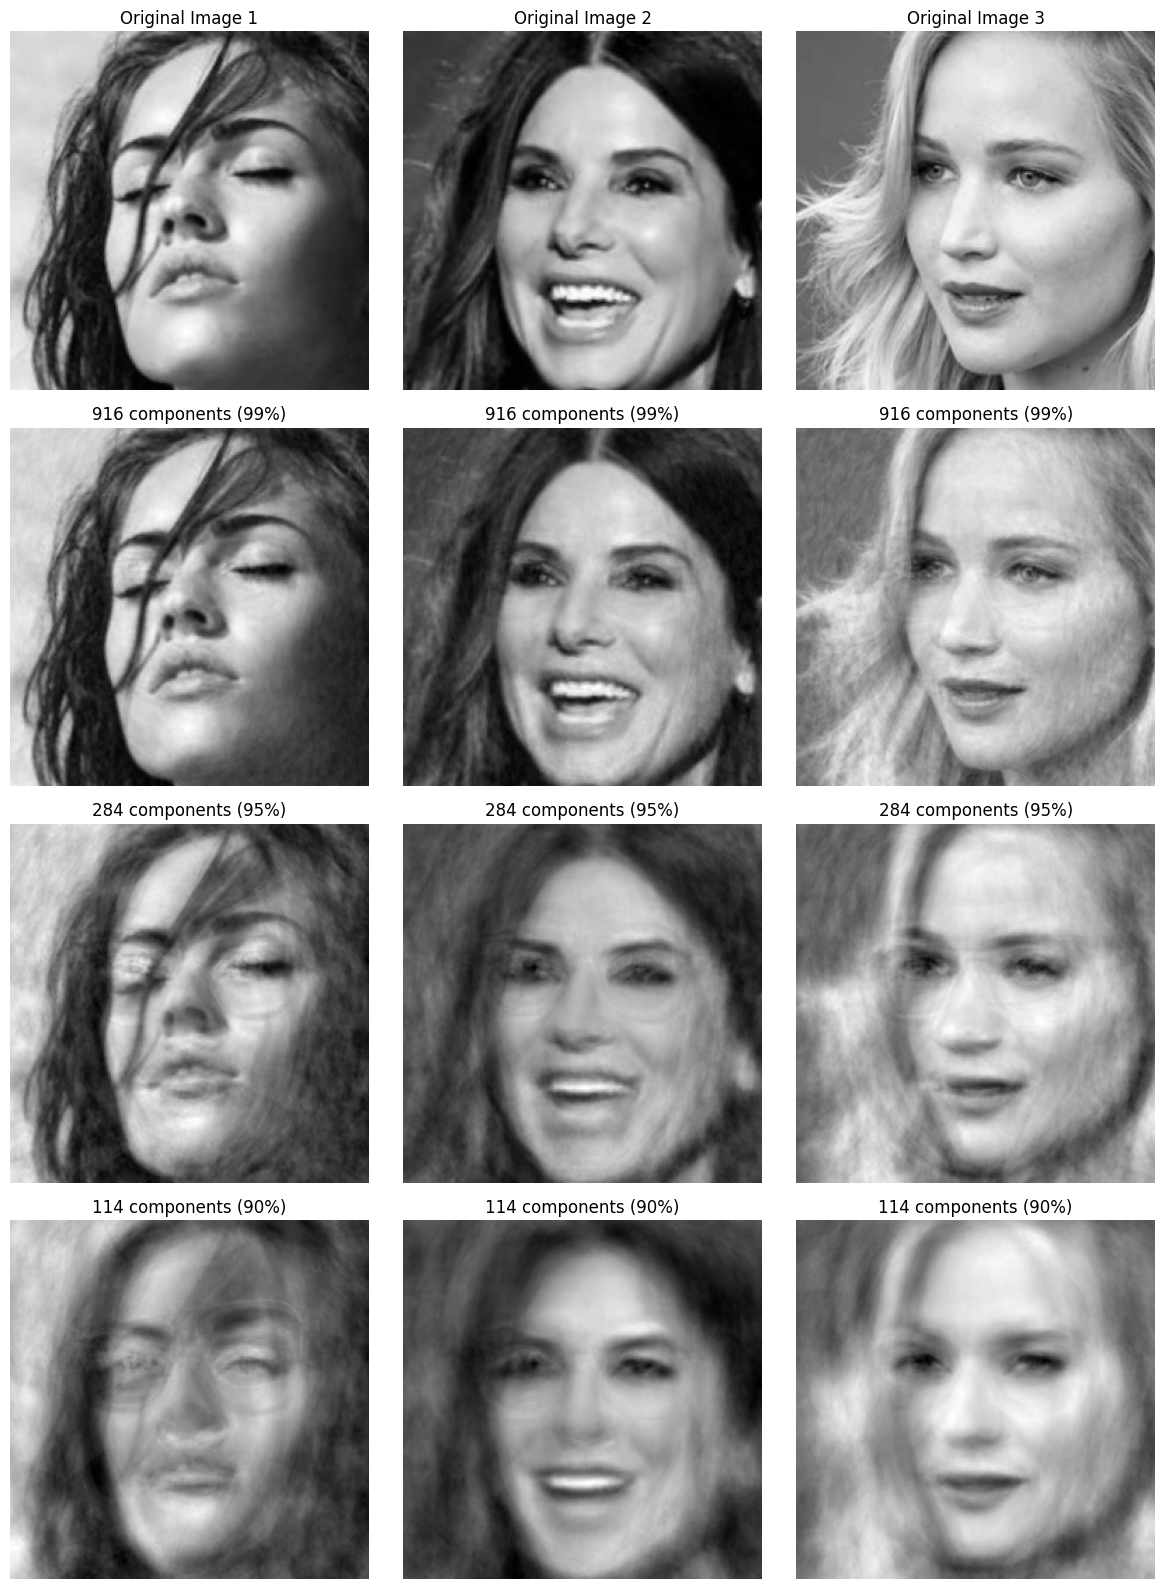

In [11]:
img1 = data[872]
img2 = data[1234]
img3 = data[456]

# Reconstruct all three images with 114, 284, and 916 components
img1_reconstructed_114, _c, _x, _m = pca.reconstruct_n(img1, 114)
img1_reconstructed_284, _c, _x, _m = pca.reconstruct_n(img1, 284)
img1_reconstructed_916, _c, _x, _m = pca.reconstruct_n(img1, 916)

img2_reconstructed_114, _c, _x, _m = pca.reconstruct_n(img2, 114)
img2_reconstructed_284, _c, _x, _m = pca.reconstruct_n(img2, 284)
img2_reconstructed_916, _c, _x, _m = pca.reconstruct_n(img2, 916)

img3_reconstructed_114, _c, _x, _m = pca.reconstruct_n(img3, 114)
img3_reconstructed_284, _c, _x, _m = pca.reconstruct_n(img3, 284)
img3_reconstructed_916, _c, _x, _m = pca.reconstruct_n(img3, 916)

# Create 4x3 plot
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# Row 0: Original images
axes[0, 0].imshow(img1.reshape(data.image_height, data.image_width), cmap='gray')
axes[0, 0].set_title('Original Image 1')
axes[0, 0].axis('off')
axes[0, 1].imshow(img2.reshape(data.image_height, data.image_width), cmap='gray')
axes[0, 1].set_title('Original Image 2')
axes[0, 1].axis('off')
axes[0, 2].imshow(img3.reshape(data.image_height, data.image_width), cmap='gray')
axes[0, 2].set_title('Original Image 3')
axes[0, 2].axis('off')

# Row 1: 916 components
axes[1, 0].imshow(img1_reconstructed_916.reshape(data.image_height, data.image_width), cmap='gray')
axes[1, 0].set_title('916 components (99%)')
axes[1, 0].axis('off')
axes[1, 1].imshow(img2_reconstructed_916.reshape(data.image_height, data.image_width), cmap='gray')
axes[1, 1].set_title('916 components (99%)')
axes[1, 1].axis('off')
axes[1, 2].imshow(img3_reconstructed_916.reshape(data.image_height, data.image_width), cmap='gray')
axes[1, 2].set_title('916 components (99%)')
axes[1, 2].axis('off')

# Row 2: 284 components
axes[2, 0].imshow(img1_reconstructed_284.reshape(data.image_height, data.image_width), cmap='gray')
axes[2, 0].set_title('284 components (95%)')
axes[2, 0].axis('off')
axes[2, 1].imshow(img2_reconstructed_284.reshape(data.image_height, data.image_width), cmap='gray')
axes[2, 1].set_title('284 components (95%)')
axes[2, 1].axis('off')
axes[2, 2].imshow(img3_reconstructed_284.reshape(data.image_height, data.image_width), cmap='gray')
axes[2, 2].set_title('284 components (95%)')
axes[2, 2].axis('off')

# Row 3: 114 components
axes[3, 0].imshow(img1_reconstructed_114.reshape(data.image_height, data.image_width), cmap='gray')
axes[3, 0].set_title('114 components (90%)')
axes[3, 0].axis('off')
axes[3, 1].imshow(img2_reconstructed_114.reshape(data.image_height, data.image_width), cmap='gray')
axes[3, 1].set_title('114 components (90%)')
axes[3, 1].axis('off')
axes[3, 2].imshow(img3_reconstructed_114.reshape(data.image_height, data.image_width), cmap='gray')
axes[3, 2].set_title('114 components (90%)')
axes[3, 2].axis('off')

plt.tight_layout()
plt.savefig("visuals/three_images_reconstruction_comparison.png", dpi=300)
plt.show()


Calculating MSE for 100 components...
Calculating MSE for 200 components...
Calculating MSE for 200 components...
Calculating MSE for 300 components...
Calculating MSE for 300 components...
Calculating MSE for 400 components...
Calculating MSE for 400 components...
Calculating MSE for 500 components...
Calculating MSE for 500 components...
Calculating MSE for 600 components...
Calculating MSE for 600 components...
Calculating MSE for 700 components...
Calculating MSE for 700 components...
Calculating MSE for 800 components...
Calculating MSE for 800 components...
Calculating MSE for 900 components...
Calculating MSE for 900 components...
Calculating MSE for 1000 components...
Calculating MSE for 1000 components...


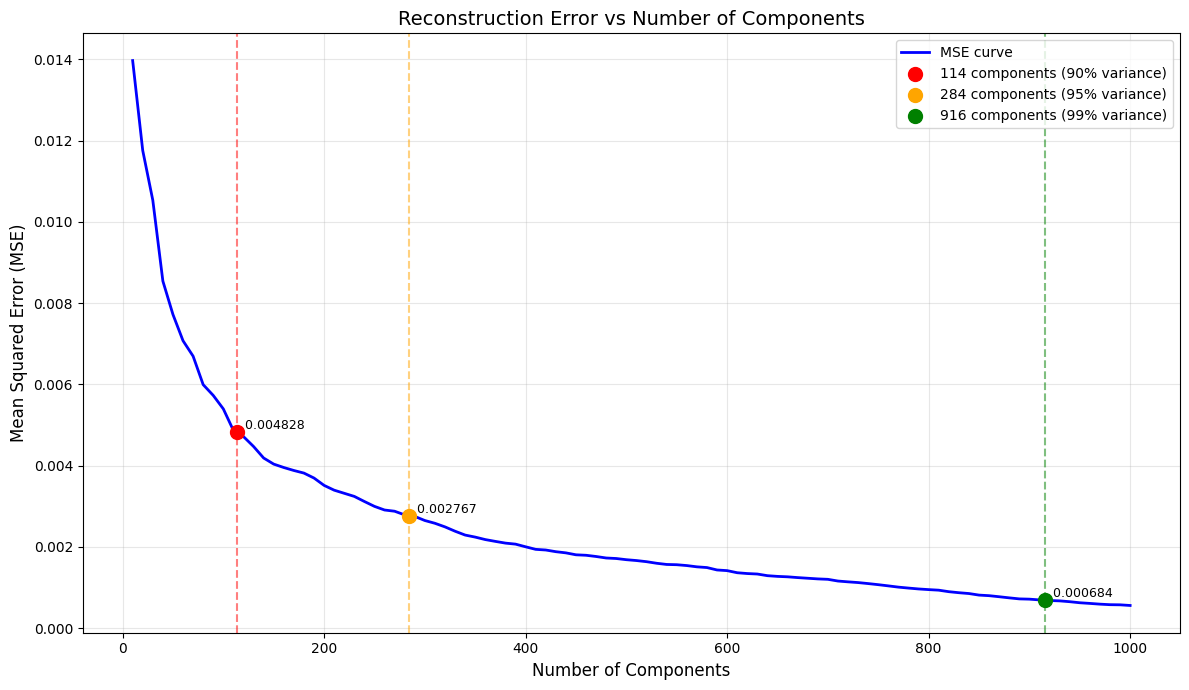


MSE values at key component counts:
  114 components: MSE = 0.004828
  284 components: MSE = 0.002767
  916 components: MSE = 0.000684


In [13]:
def MSE(original, reconstructed):

    return np.mean((original - reconstructed) ** 2)

image = data[827]

# Include specific component values and range
num_components = sorted(set(list(range(10, 1010, 10)) + [114, 284, 916]))

mse_values = []
for n in num_components:
    if n%100 == 0:
        print(f"Calculating MSE for {n} components...")
    reconstructed, components_sub, X_transformed, mean = pca.reconstruct_n(image, n)
    mse = MSE(image, reconstructed)
    mse_values.append(mse)

# Find MSE values for specific components
special_components = [114, 284, 916]
special_indices = [num_components.index(n) for n in special_components]
special_mse = [mse_values[i] for i in special_indices]

plt.figure(figsize=(12, 7))
plt.plot(num_components, mse_values, 'b-', linewidth=2, label='MSE curve')

# Mark special points
colors = ['red', 'orange', 'green']
labels = ['90% variance', '95% variance', '99% variance']
for comp, mse, color, label in zip(special_components, special_mse, colors, labels):
    plt.scatter(comp, mse, color=color, s=100, zorder=5, label=f'{comp} components ({label})')
    plt.axvline(x=comp, color=color, linestyle='--', alpha=0.5)
    plt.text(comp, mse, f'  {mse:.6f}', fontsize=9, verticalalignment='bottom')

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Reconstruction Error vs Number of Components', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visuals/reconstruction_error.png', dpi=300)
plt.show()

print(f"\nMSE values at key component counts:")
for comp, mse in zip(special_components, special_mse):
    print(f"  {comp} components: MSE = {mse:.6f}")